In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [12]:
insurance = pd.read_csv("insurance.csv")

In [14]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [26]:
X = insurance.drop(columns = ['charges'])
y = insurance['charges']
X['sex'] =  X['sex'].map({'female':1, 'male':0})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})
X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']
X = pd.get_dummies(X, columns = ['region'], drop_first = True, dtype = int)

In [46]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

# regression_model = LinearRegression()
# regression_model.fit(X_train, y_train)

# y_pred1 = regression_model.predict(X_test)

# r2 = r2_score(y_test, y_pred1)
# print(r2)



0.8652316979531681


0.8652317499453056
0.8652368821092624
0.8652818224324137
0.8653251311074115
0.8654360700729831
0.8655522449862072
0.8655201511986084
0.865135560392281
0.864433779537986
0.8634647648428347
0.8555661679392098


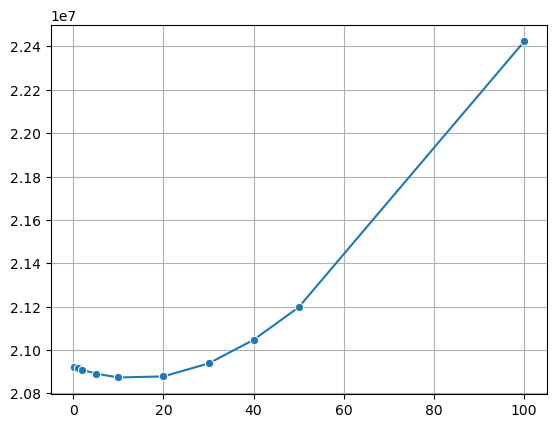

In [81]:
#  This is a onyl for the Overfiting

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []
for a in alphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    y_pred2 = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred2)
    mses.append(mse)
    r2_score1 = r2_score(y_test, y_pred2) # for the every value r2_score was different 
    print(r2_score1) 
    
sns.lineplot(x=alphas, y=mses, marker='o')
plt.grid()

In [85]:
#  THis is for Underfiting 
#  LassoCV Model ko iter hamesha jya hi chahiye 

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000, 
    random_state = 42
)
lasso_cv_model = lasso_cv_model.fit(X_train, y_train)

print(f"LassoCV's Alphas is", lasso_cv_model.alpha_)
y_pred3 = lasso_cv_model.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred3)
r2_score3 = r2_score(y_test, y_pred3)
print(r2_score3)


LassoCV's Alphas is 0.001
0.8652317499453056
